##  Modelo Base de Machine Learning

### By:
Maria Camila Sepulveda Torres

### Date:
2026-08-21

### Description:

En este notebook se construye un modelo base para estimar `Chance of Admit`, utilizando una modelo base DummyRegressor basada en los resultados obtenidos durante el análisis exploratorio de datos.



## 📚 Import  libraries

In [ ]:
# librerías base para ciencia de datos
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

## 💾 Load data

In [30]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admission_type_fixed.parquet",
    engine="pyarrow",
)

In [31]:
# versiones de las librerías para garantizar reproducibilidad

print("Versión de Pandas: ", pd.__version__)

Versión de Pandas:  3.0.5


## 👷 Data preparation or Feature Engineering

In [32]:
selected_features = [
    "CGPA",
    "Chance of Admit",
]

admission_features = admission_df[selected_features].copy()

admission_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CGPA             621 non-null    float64
 1   Chance of Admit  623 non-null    float64
dtypes: float64(2)
memory usage: 9.9 KB


In [33]:
admission_features.isna().sum()

CGPA               2
Chance of Admit    0
dtype: int64

In [34]:
duplicate_rows = admission_features.duplicated().sum()

print("Número de filas duplicadas: ", duplicate_rows)

Número de filas duplicadas:  245


In [35]:
admission_features.groupby("CGPA")["Chance of Admit"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_index()

,count,mean,median,min,max
CGPA,,,,,
6.80,1,0.360,0.36,0.36,0.36
7.20,1,0.460,0.46,0.46,0.46
7.25,1,0.570,0.57,0.57,0.57
7.28,3,0.470,0.47,0.47,0.47
7.30,1,0.540,0.54,0.54,0.54
...,...,...,...,...,...
9.80,5,0.958,0.96,0.94,0.97
9.82,1,0.960,0.96,0.96,0.96
9.87,2,0.970,0.97,0.97,0.97


In [36]:
cgpa_analysis = admission_features.copy()

cgpa_analysis["CGPA_range"] = pd.cut(
    cgpa_analysis["CGPA"],
    bins=[0, 8.0, 8.5, 9.0, 9.5, 10.0],
    labels=[
        "CGPA <= 8.0",
        "8.0 < CGPA <= 8.5",
        "8.5 < CGPA <= 9.0",
        "9.0 < CGPA <= 9.5",
        "CGPA > 9.5",
    ],
)

cgpa_analysis.groupby("CGPA_range", observed=True)["Chance of Admit"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
CGPA_range,,,,,
CGPA <= 8.0,92,0.535435,0.530,0.34,0.78
8.0 < CGPA <= 8.5,173,0.658902,0.660,0.34,0.81
8.5 < CGPA <= 9.0,166,0.746988,0.760,0.45,0.87
9.0 < CGPA <= 9.5,152,0.866842,0.885,0.61,0.96
CGPA > 9.5,38,0.950000,0.955,0.89,0.97


### Selección de la variable más importante

A partir del análisis exploratorio realizado, se selecciona `CGPA` como la variable más importante para el problema, debido a la relación observada entre esta característica y la variable objetivo `Chance of Admit`.

El análisis por rangos de `CGPA` muestra un incremento progresivo en el valor promedio de `Chance of Admit`. Para valores de `CGPA` menores o iguales a 8.0, el promedio de la variable objetivo es aproximadamente 0.54, mientras que para valores superiores a 9.5 alcanza aproximadamente 0.95.

Este comportamiento evidencia que, a medida que aumenta el `CGPA`, también tiende a aumentar la probabilidad de admisión, por lo que se considera una variable relevante para el desarrollo de modelos predictivos posteriores.

Sin embargo, el modelo base seleccionado en este notebook es un `DummyRegressor` con estrategia basada en la media. Por esta razón, `CGPA` no se utiliza directamente para generar las predicciones del modelo base. Su selección permite identificar una característica relevante que podrá ser aprovechada posteriormente por modelos con capacidad de aprender relaciones entre las variables predictoras y `Chance of Admit`.

In [37]:
cols_numeric = [
    "GRE Score",
    "TOEFL Score",
    "CGPA",
]

cols_categoric_ord = [
    "University Rating",
    "SOP",
    "LOR",
]

cols_boolean = [
    "Research",
]

In [38]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_ord_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

boolean_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, cols_numeric),
        ("categoric ordinales", categorical_ord_pipe, cols_categoric_ord),
        ("boolean", boolean_pipe, cols_boolean),
    ]
)

In [39]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinales', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_na

## Train / Test split

In [40]:
selected_features = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance of Admit",
]

admission_model = admission_df[selected_features].copy()

# eliminar registros duplicados
admission_model = admission_model.drop_duplicates()

admission_model.info()

<class 'pandas.DataFrame'>
Index: 471 entries, 0 to 581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          460 non-null    Int16  
 1   TOEFL Score        452 non-null    Int16  
 2   University Rating  465 non-null    float64
 3   SOP                455 non-null    float64
 4   LOR                463 non-null    float64
 5   CGPA               469 non-null    float64
 6   Research           442 non-null    boolean
 7   Chance of Admit    471 non-null    float64
dtypes: Int16(2), boolean(1), float64(5)
memory usage: 25.8 KB


In [41]:
X_features = admission_model.drop(
    "Chance of Admit",
    axis="columns",
)

Y_target = admission_model["Chance of Admit"]

In [42]:
X_features.shape, Y_target.shape

((471, 7), (471,))

In [43]:
# 80% entrenamiento, 20% prueba
x_train, x_test, y_train, y_test = train_test_split(
    X_features,
    Y_target,
    test_size=0.2,
    random_state=42,
)

In [44]:
x_train.shape, y_train.shape

((376, 7), (376,))

In [45]:
x_test.shape, y_test.shape

((95, 7), (95,))

## Modelo

In [46]:
# modelo base
model = DummyRegressor(strategy="mean")

In [47]:
# pipeline del modelo = preprocesador + modelo base
model_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

model_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinales', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold:

## Predicción y evaluación

In [48]:
model_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['GRE Score','TOEFL Score','University Rating',...,'LOR','CGPA','Research']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinales', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thro

In [50]:
y_pred = model_pipe.predict(x_test)

In [51]:
y_pred[:10]

array([0.72367021, 0.72367021, 0.72367021, 0.72367021, 0.72367021,
       0.72367021, 0.72367021, 0.72367021, 0.72367021, 0.72367021])

### Métricas de evaluación

In [52]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R²: ", r2)

MAE:  0.12098600223964166
RMSE:  0.1484907993588229
R²:  -7.51467297899211e-06


## Cross Validation

Se utiliza validación cruzada para evaluar la estabilidad del modelo base en diferentes particiones de los datos de entrenamiento.

Se calculan diferentes métricas de regresión y se obtiene la media y la desviación estándar de los resultados.

In [53]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [54]:
mae_scores = -cross_val_score(
    model_pipe,
    x_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
)

print("MAE por fold:", mae_scores)
print("MAE promedio:", mae_scores.mean())
print("Desviación estándar:", mae_scores.std())

MAE por fold: [0.10482105 0.12373422 0.1227588  0.11527796 0.10449878]
MAE promedio: 0.11421816401468787
Desviación estándar: 0.008335383656202454


In [55]:
rmse_scores = -cross_val_score(
    model_pipe,
    x_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
)

print("RMSE por fold:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())
print("Desviación estándar:", rmse_scores.std())

RMSE por fold: [0.12606453 0.15197454 0.15782927 0.14494199 0.13047574]
RMSE promedio: 0.14225721453669088
Desviación estándar: 0.012207615898467604


In [56]:
r2_scores = cross_val_score(
    model_pipe,
    x_train,
    y_train,
    cv=cv,
    scoring="r2",
)

print("R² por fold:", r2_scores)
print("R² promedio:", r2_scores.mean())
print("Desviación estándar:", r2_scores.std())

R² por fold: [-0.02618314 -0.01433529 -0.01070572 -0.03753802 -0.00172133]
R² promedio: -0.01809670019842411
Desviación estándar: 0.012492261448893125


In [57]:
cv_results_df = pd.DataFrame(
    {
        "MAE": mae_scores,
        "RMSE": rmse_scores,
        "R2": r2_scores,
    }
)

cv_results_df

,MAE,RMSE,R2
0,0.104821,0.126065,-0.026183
1,0.123734,0.151975,-0.014335
2,0.122759,0.157829,-0.010706
3,0.115278,0.144942,-0.037538
4,0.104499,0.130476,-0.001721


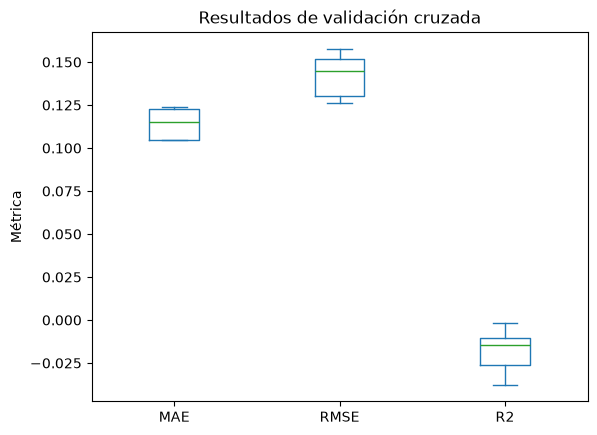

In [58]:
cv_results_df.plot.box(
    title="Resultados de validación cruzada",
    ylabel="Métrica",
)

plt.show()

## Selección de la métrica principal

Se selecciona el **MAE (Mean Absolute Error)** como la métrica principal para evaluar y comparar los modelos posteriores.

El MAE representa el error absoluto promedio entre el valor real y el valor predicho de `Chance of Admit`. Se selecciona debido a que permite interpretar directamente el error en la misma escala de la variable objetivo.

En la validación cruzada, el modelo base obtuvo un MAE promedio de aproximadamente **0.1142**, con una desviación estándar de **0.0083**, lo que indica un comportamiento relativamente estable entre las diferentes particiones evaluadas.

Este resultado será utilizado como referencia para los modelos posteriores, buscando obtener valores de MAE inferiores a los obtenidos por el modelo base.

In [59]:
cv_summary = pd.DataFrame(
    {
        "Métrica": ["MAE", "RMSE", "R²"],
        "Media CV": [
            mae_scores.mean(),
            rmse_scores.mean(),
            r2_scores.mean(),
        ],
        "Desviación estándar CV": [
            mae_scores.std(),
            rmse_scores.std(),
            r2_scores.std(),
        ],
    }
)

cv_summary

,Métrica,Media CV,Desviación estándar CV
0,MAE,0.114218,0.008335
1,RMSE,0.142257,0.012208
2,R²,-0.018097,0.012492


In [60]:
y_train_pred = model_pipe.predict(x_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

In [61]:
metrics_df = pd.DataFrame(
    {
        "Métrica": ["MAE", "RMSE", "R²"],
        "Train": [
            train_mae,
            train_rmse,
            train_r2,
        ],
        "CV Mean": [
            mae_scores.mean(),
            rmse_scores.mean(),
            r2_scores.mean(),
        ],
        "CV Std": [
            mae_scores.std(),
            rmse_scores.std(),
            r2_scores.std(),
        ],
    }
)

metrics_df

,Métrica,Train,CV Mean,CV Std
0,MAE,0.114023,0.114218,0.008335
1,RMSE,0.142287,0.142257,0.012208
2,R²,0.000000,-0.018097,0.012492


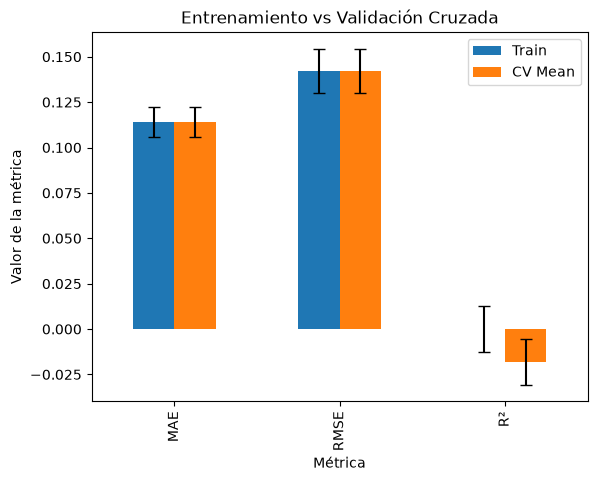

In [62]:
metrics_df.plot(
    kind="bar",
    x="Métrica",
    y=["Train", "CV Mean"],
    yerr="CV Std",
    title="Entrenamiento vs Validación Cruzada",
    ylabel="Valor de la métrica",
    capsize=4,
)

plt.show()

### Análisis de la validación cruzada

Los resultados de entrenamiento y validación cruzada presentan valores similares para las métricas MAE y RMSE, lo que evidencia un comportamiento estable del modelo base entre las diferentes particiones de los datos.

El MAE obtenido mediante validación cruzada fue aproximadamente 0.1142, mientras que el RMSE fue aproximadamente 0.1423. La diferencia entre ambas métricas indica la presencia de algunos errores de mayor magnitud, debido a que el RMSE penaliza con mayor intensidad las diferencias grandes entre los valores reales y predichos.

Por otra parte, el R² promedio de validación cruzada fue -0.0181, valor cercano a cero y ligeramente negativo. Este comportamiento es esperado para un DummyRegressor basado en la media, debido a que el modelo no utiliza las relaciones existentes entre las variables predictoras para explicar la variabilidad de `Chance of Admit`.

La similitud entre los resultados de entrenamiento y validación cruzada indica que no se evidencia una diferencia importante entre el desempeño del modelo en ambos conjuntos. Sin embargo, su capacidad predictiva es limitada, lo cual es consistente con su propósito como modelo base de referencia.


## Evaluacion final

In [67]:
y_pred = model_pipe.predict(x_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final R²:", final_r2)

Final MAE: 0.12098600223964166
Final RMSE: 0.1484907993588229
Final R²: -7.51467297899211e-06


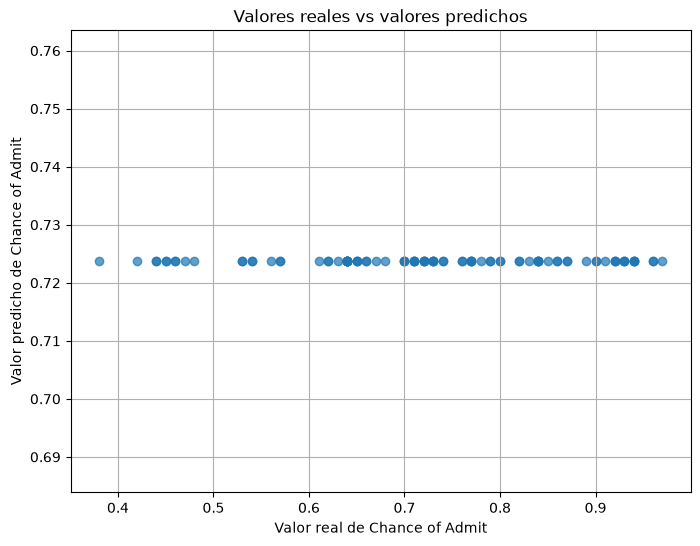

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Valor real de Chance of Admit")
plt.ylabel("Valor predicho de Chance of Admit")
plt.title("Valores reales vs valores predichos")

plt.grid()

plt.show()

### (MAE)

Se selecciona el **MAE (Mean Absolute Error)** como la métrica principal para evaluar el desempeño del modelo base.

El MAE mide la diferencia absoluta promedio entre los valores reales y los valores predichos de `Chance of Admit`. Esta métrica se selecciona porque su resultado se expresa en la misma escala de la variable objetivo, lo que facilita su interpretación.

En la evaluación final, el modelo base obtuvo un MAE de aproximadamente **0.1210**, lo que indica que las predicciones presentan, en promedio, una diferencia absoluta de aproximadamente 0.12 respecto a los valores reales de `Chance of Admit`.

Adicionalmente, el modelo obtuvo un R² cercano a cero, lo cual evidencia su limitada capacidad para explicar la variabilidad de la variable objetivo. Este comportamiento es esperado debido a que el `DummyRegressor` utilizado como modelo base realiza sus predicciones a partir de la media de la variable objetivo.

Por lo tanto, el MAE obtenido por este modelo constituye una referencia para evaluar modelos posteriores. Se espera que un modelo de machine learning con mayor capacidad predictiva obtenga un MAE inferior al alcanzado por este modelo base.

## Learning Curve


In [69]:
# definir nuevamente pipeline = preprocesador + modelo base
model = DummyRegressor(strategy="mean")

model_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

# parámetros para la curva de aprendizaje
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(
        n_splits=50,
        test_size=0.2,
        random_state=123,
    ),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "neg_mean_absolute_error"

# obtener los valores de la curva de aprendizaje
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model_pipe,
    **common_params,
    scoring=scoring_metric,
)

# convertir los valores negativos de sklearn a MAE positivo
train_scores = -train_scores
test_scores = -test_scores

# calcular media y desviación estándar de los scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# calcular media y desviación estándar de los tiempos
fit_times_mean = np.mean(fit_times, axis=1)
fit_times_std = np.std(fit_times, axis=1)

score_times_mean = np.mean(score_times, axis=1)
score_times_std = np.std(score_times, axis=1)

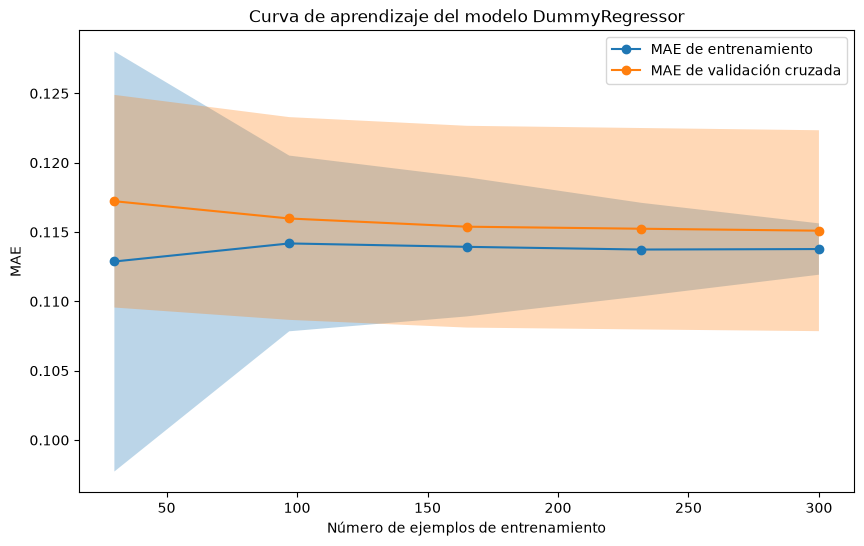

Tamaños de entrenamiento: [ 30  97 165 232 300]
MAE promedio de entrenamiento: [0.11287511 0.11417723 0.11393277 0.11373723 0.11377316]
Desviación estándar del MAE de entrenamiento: [0.01514296 0.00633522 0.00501937 0.00336692 0.00185095]
MAE promedio de validación cruzada: [0.11722246 0.11597632 0.11538496 0.11523748 0.11509626]
Desviación estándar del MAE de validación cruzada: [0.00766636 0.00730957 0.0072747  0.00726254 0.00724346]


In [76]:
# gráfica de la curva de aprendizaje
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(10, 6),
)

ax.plot(
    train_sizes,
    train_mean,
    "o-",
    label="MAE de entrenamiento",
)

ax.plot(
    train_sizes,
    test_mean,
    "o-",
    label="MAE de validación cruzada",
)

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.3,
)

ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.3,
)

ax.set_title(f"Curva de aprendizaje del modelo {model.__class__.__name__}")
ax.set_xlabel("Número de ejemplos de entrenamiento")
ax.set_ylabel("MAE")
ax.legend(loc="best")

plt.show()

# valores para el análisis
print("Tamaños de entrenamiento:", train_sizes)
print("MAE promedio de entrenamiento:", train_mean)
print("Desviación estándar del MAE de entrenamiento:", train_std)
print("MAE promedio de validación cruzada:", test_mean)
print("Desviación estándar del MAE de validación cruzada:", test_std)

## ESCALABILIDAD

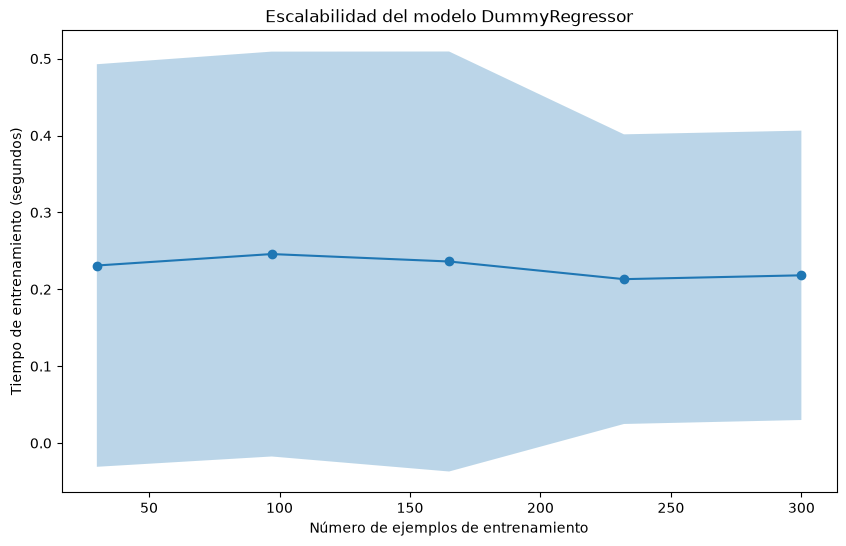

Tamaños de entrenamiento: [ 30  97 165 232 300]
Tiempo promedio de entrenamiento: [0.23093778 0.24584172 0.23616004 0.21319345 0.21818193]
Desviación estándar del tiempo de entrenamiento: [0.26182403 0.26331521 0.27314884 0.18837638 0.18820105]


In [75]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    fit_times_mean,
    "o-",
)

plt.fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)

plt.title(f"Escalabilidad del modelo {model.__class__.__name__}")
plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Tiempo de entrenamiento (segundos)")

plt.show()

print("Tamaños de entrenamiento:", train_sizes)
print("Tiempo promedio de entrenamiento:", fit_times_mean)
print("Desviación estándar del tiempo de entrenamiento:", fit_times_std)

### Rendimiento del modelo

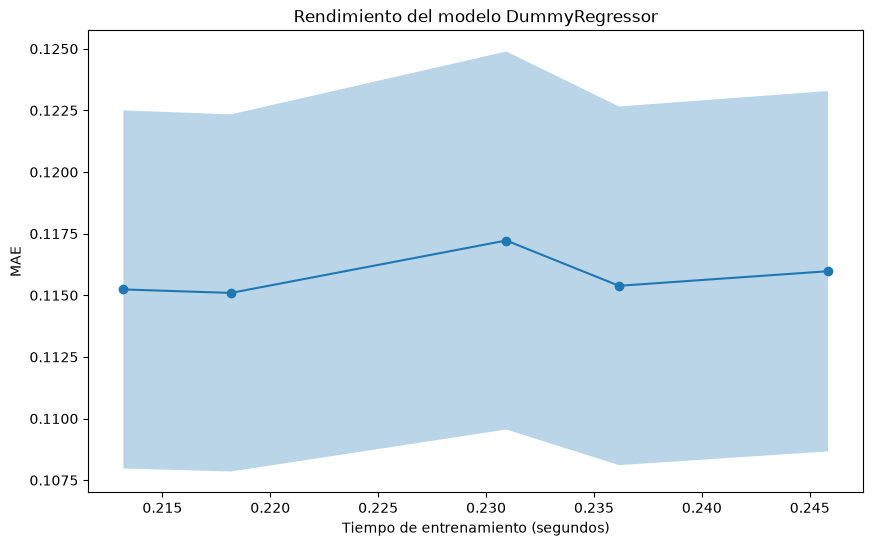

Tiempo promedio de entrenamiento: [0.23093778 0.24584172 0.23616004 0.21319345 0.21818193]
MAE promedio de validación: [0.11722246 0.11597632 0.11538496 0.11523748 0.11509626]
Desviación estándar del MAE: [0.00766636 0.00730957 0.0072747  0.00726254 0.00724346]


In [73]:
# ordenar los resultados según el tiempo de entrenamiento
orden = np.argsort(fit_times_mean)

fit_times_sorted = fit_times_mean[orden]
test_mean_sorted = test_mean[orden]
test_std_sorted = test_std[orden]

plt.figure(figsize=(10, 6))

plt.plot(
    fit_times_sorted,
    test_mean_sorted,
    "o-",
)

plt.fill_between(
    fit_times_sorted,
    test_mean_sorted - test_std_sorted,
    test_mean_sorted + test_std_sorted,
    alpha=0.3,
)

plt.title(f"Rendimiento del modelo {model.__class__.__name__}")
plt.xlabel("Tiempo de entrenamiento (segundos)")
plt.ylabel("MAE")

plt.show()

print("Tiempo promedio de entrenamiento:", fit_times_mean)
print("MAE promedio de validación:", test_mean)
print("Desviación estándar del MAE:", test_std)

### Tiempo de evaluación del modelo

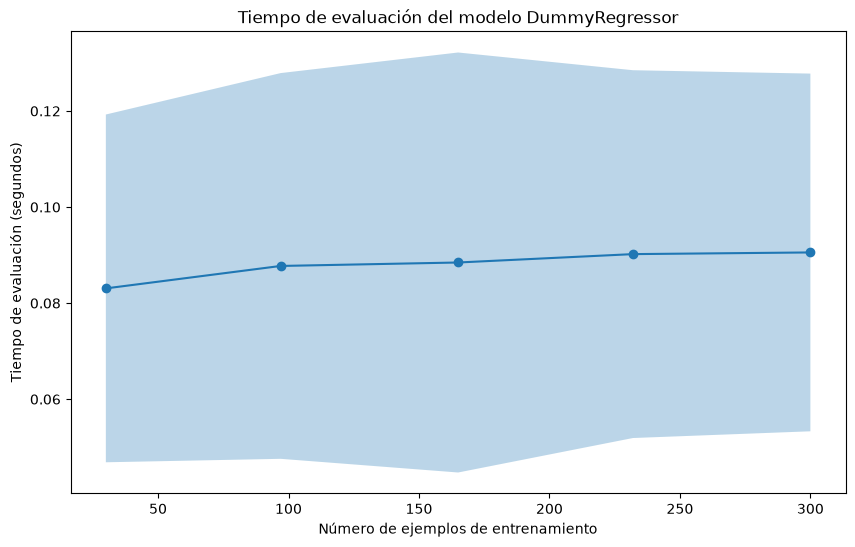

Tamaños de entrenamiento: [ 30  97 165 232 300]
Tiempo promedio de entrenamiento: [0.23093778 0.24584172 0.23616004 0.21319345 0.21818193]
Desviación estándar del tiempo de entrenamiento: [0.26182403 0.26331521 0.27314884 0.18837638 0.18820105]
Tiempo promedio de evaluación: [0.08306375 0.08773638 0.08845552 0.09019977 0.09054883]
Desviación estándar del tiempo de evaluación: [0.03620026 0.04015409 0.0437198  0.03828709 0.03723626]


In [74]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    score_times_mean,
    "o-",
)

plt.fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)

plt.title(f"Tiempo de evaluación del modelo {model.__class__.__name__}")
plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Tiempo de evaluación (segundos)")

plt.show()

print("Tamaños de entrenamiento:", train_sizes)
print("Tiempo promedio de entrenamiento:", fit_times_mean)
print("Desviación estándar del tiempo de entrenamiento:", fit_times_std)
print("Tiempo promedio de evaluación:", score_times_mean)
print("Desviación estándar del tiempo de evaluación:", score_times_std)

## 📊 Analysis of Results and Conclusions 

Los resultados obtenidos permiten analizar el comportamiento del modelo base `DummyRegressor` desde el desempeño predictivo, la estabilidad y la escalabilidad.

### Desempeño del modelo base

En la evaluación final sobre el conjunto de prueba se obtuvo un MAE de aproximadamente **0.1210**, un RMSE de **0.1485** y un R² cercano a **0**.

El MAE indica que las predicciones del modelo presentan, en promedio, una diferencia absoluta cercana a 0.12 respecto al valor real de `Chance of Admit`. Por su parte, el RMSE es superior al MAE, lo que evidencia la existencia de errores de mayor magnitud en algunas observaciones.

El R² cercano a cero evidencia que el modelo base prácticamente no explica la variabilidad de la variable objetivo. Este resultado es esperado debido a que el `DummyRegressor` utiliza una estrategia basada en la media y no aprende las relaciones existentes entre las variables predictoras y `Chance of Admit`.

### Validación cruzada

La validación cruzada obtuvo un MAE promedio de **0.1142**, con una desviación estándar de **0.0083**, y un RMSE promedio de **0.1423**, con una desviación estándar de **0.0122**.

La baja variabilidad entre las diferentes particiones indica que el comportamiento del modelo base es relativamente estable. Sin embargo, esta estabilidad no implica una alta capacidad predictiva, debido a que el modelo mantiene una estrategia simple de predicción.

### Curva de aprendizaje

La curva de aprendizaje muestra que el MAE de entrenamiento y el MAE de validación cruzada convergen aproximadamente alrededor de **0.114 - 0.115** a medida que aumenta el número de ejemplos de entrenamiento.

La pequeña diferencia entre ambas curvas no evidencia un comportamiento de sobreajuste. Por el contrario, la estabilización del error muestra que aumentar la cantidad de datos no genera una mejora significativa en el desempeño del modelo base.

Este comportamiento es consistente con la limitada capacidad del `DummyRegressor`, ya que el modelo no aprende patrones complejos de los datos.

### Escalabilidad

Los tiempos de entrenamiento y evaluación permanecen relativamente estables al aumentar el número de observaciones. El tiempo promedio de evaluación se mantiene aproximadamente entre **0.083 y 0.091 segundos**.

Esto evidencia un bajo costo computacional del modelo base. Sin embargo, el aumento en la cantidad de datos no produce una reducción significativa del MAE, por lo que la principal limitación del modelo no corresponde a la cantidad de información disponible, sino a su baja capacidad predictiva.

## Conclusiones

El modelo base `DummyRegressor` permitió establecer un punto de referencia para evaluar posteriormente modelos de machine learning con mayor capacidad predictiva.

Los resultados muestran que el modelo presenta un MAE de aproximadamente **0.1210** en el conjunto de prueba y un MAE promedio de **0.1142** mediante validación cruzada. La cercanía entre estos valores indica un comportamiento estable entre las diferentes particiones de los datos.

El R² obtenido fue cercano a cero, lo que confirma que el modelo base no logra explicar la variabilidad de `Chance of Admit`. Este resultado es coherente con el funcionamiento del `DummyRegressor`, ya que utiliza una estrategia basada en la media de la variable objetivo y no aprende relaciones entre las variables predictoras.

La curva de aprendizaje muestra que los errores de entrenamiento y validación convergen a medida que aumenta el número de observaciones. No se evidencia sobreajuste; sin embargo, el desempeño se estabiliza sin presentar mejoras significativas, lo que refleja la limitada capacidad predictiva del modelo base.

Finalmente, el análisis de escalabilidad evidencia tiempos de entrenamiento y evaluación bajos y relativamente estables. Por lo tanto, el principal aspecto por mejorar no corresponde al costo computacional, sino a la capacidad del modelo para aprender las relaciones presentes en los datos.

En consecuencia, los modelos desarrollados posteriormente deberán superar el desempeño de este modelo base, principalmente obteniendo un **MAE inferior a 0.1210** en el conjunto de prueba y un R² superior al obtenido por el `DummyRegressor`.

## Recomendaciones

A partir de los resultados obtenidos con el modelo base `DummyRegressor`, se recomienda desarrollar y evaluar modelos de regresión con mayor capacidad para aprender las relaciones existentes entre las variables predictoras y la variable objetivo `Chance of Admit`.

El **MAE** debe mantenerse como la métrica principal de comparación, tomando como referencia el valor de aproximadamente **0.1210** obtenido por el modelo base en el conjunto de prueba. Por lo tanto, los modelos posteriores deberán buscar un MAE inferior a este valor. De manera complementaria, se recomienda continuar evaluando el RMSE y el R² para analizar la magnitud de los errores y la capacidad explicativa de los nuevos modelos.

Se recomienda mantener el **pipeline de preprocesamiento** dentro del proceso de entrenamiento y validación, garantizando que las transformaciones e imputaciones sean aprendidas únicamente a partir de los datos de entrenamiento y reduciendo así el riesgo de fuga de información (*data leakage*).

Como siguientes alternativas, se recomienda evaluar inicialmente modelos de regresión interpretables, como la **regresión lineal** y los **árboles de decisión**, y posteriormente comparar su desempeño con modelos de mayor flexibilidad, como **Random Forest**.

La comparación entre los modelos deberá realizarse utilizando la misma división de datos, estrategia de validación cruzada y métricas utilizadas para el modelo base, con el fin de garantizar que los resultados sean comparables.

Finalmente, se recomienda analizar la importancia de las variables predictoras en los modelos posteriores, prestando especial atención a `CGPA`, identificada previamente como una variable relevante por su relación con `Chance of Admit`.

## 💡 Propuestas e ideas

A partir de los resultados obtenidos con el modelo base, se propone utilizar su desempeño como punto de referencia para el desarrollo y comparación de modelos de regresión con mayor capacidad predictiva.

Como primera alternativa, se propone implementar un modelo de regresión lineal debido a su facilidad de interpretación y a las relaciones observadas entre las variables académicas y `Chance of Admit`.

Posteriormente, se pueden evaluar modelos como árboles de decisión y Random Forest con el propósito de identificar posibles relaciones no lineales entre las características de los aspirantes y la variable objetivo.

Los nuevos modelos deberán evaluarse utilizando las mismas métricas empleadas para el modelo base, principalmente MAE, complementado con RMSE y R². Se considerará una mejora cuando el modelo obtenga un MAE inferior al alcanzado por el `DummyRegressor` y presente un comportamiento estable durante la validación cruzada.

También se propone analizar la importancia de las variables predictoras en los modelos posteriores, con el objetivo de determinar cuáles características aportan mayor información para estimar `Chance of Admit`.

Finalmente, se propone conservar el pipeline de preprocesamiento dentro de los procesos de entrenamiento y validación para asegurar que las transformaciones sean aprendidas únicamente a partir de los datos correspondientes al entrenamiento y reducir el riesgo de fuga de información (*data leakage*).